In [157]:
stages = [
    'Get a PhD Response',
    'Get a PhD Position',
    'Avoid Desk Rejection',
    'Be a Published PhD Student',
    'Get a Good Track Record',
    'Get a Tenure Track Job',
    'Get an Award',
    'Get Tenure',
]

stages_wrapped= [
    "PhD\nInquiry",
    "PhD\nAdmission",
    "Desk\nRejection",
    "Paper\nAcceptance",
    "Publication\nTrack Record",
    "Tenure\nTrack Job",
    "Award",
    "Tenure",
]

# model_colors = {
#     'Claude 3.5 v1': '#FFCCCC',
#     'Claude 3.5 v2': '#FF6666',
#     'Claude 3.7': 'crimson',
#     'LLaMA 3-70b': 'purple',
#     'GPT-4o': 'green'
# }
# Consistent ordered model labels
ordered_labels = [
    "Claude 3.5 v1",
    "Claude 3.5 v2",
    "Claude 3.7",
    "LLaMA 3-70b",
    "GPT-4o"
]

# Match each model name to its color
model_colors = {
    "Claude 3.5 v1": "#FFCCCC",
    "Claude 3.5 v2": "#FF6666",
    "Claude 3.7": "crimson",
    "LLaMA 3-70b": "purple",
    "GPT-4o": "green"
}


pushed_stage_name = 'Feel Pushed from Tenure'
pushed_stage_display_name = "Feeling\nPushed out"
average_stage_name = "All stages averaged"

### Figure3 World Plots

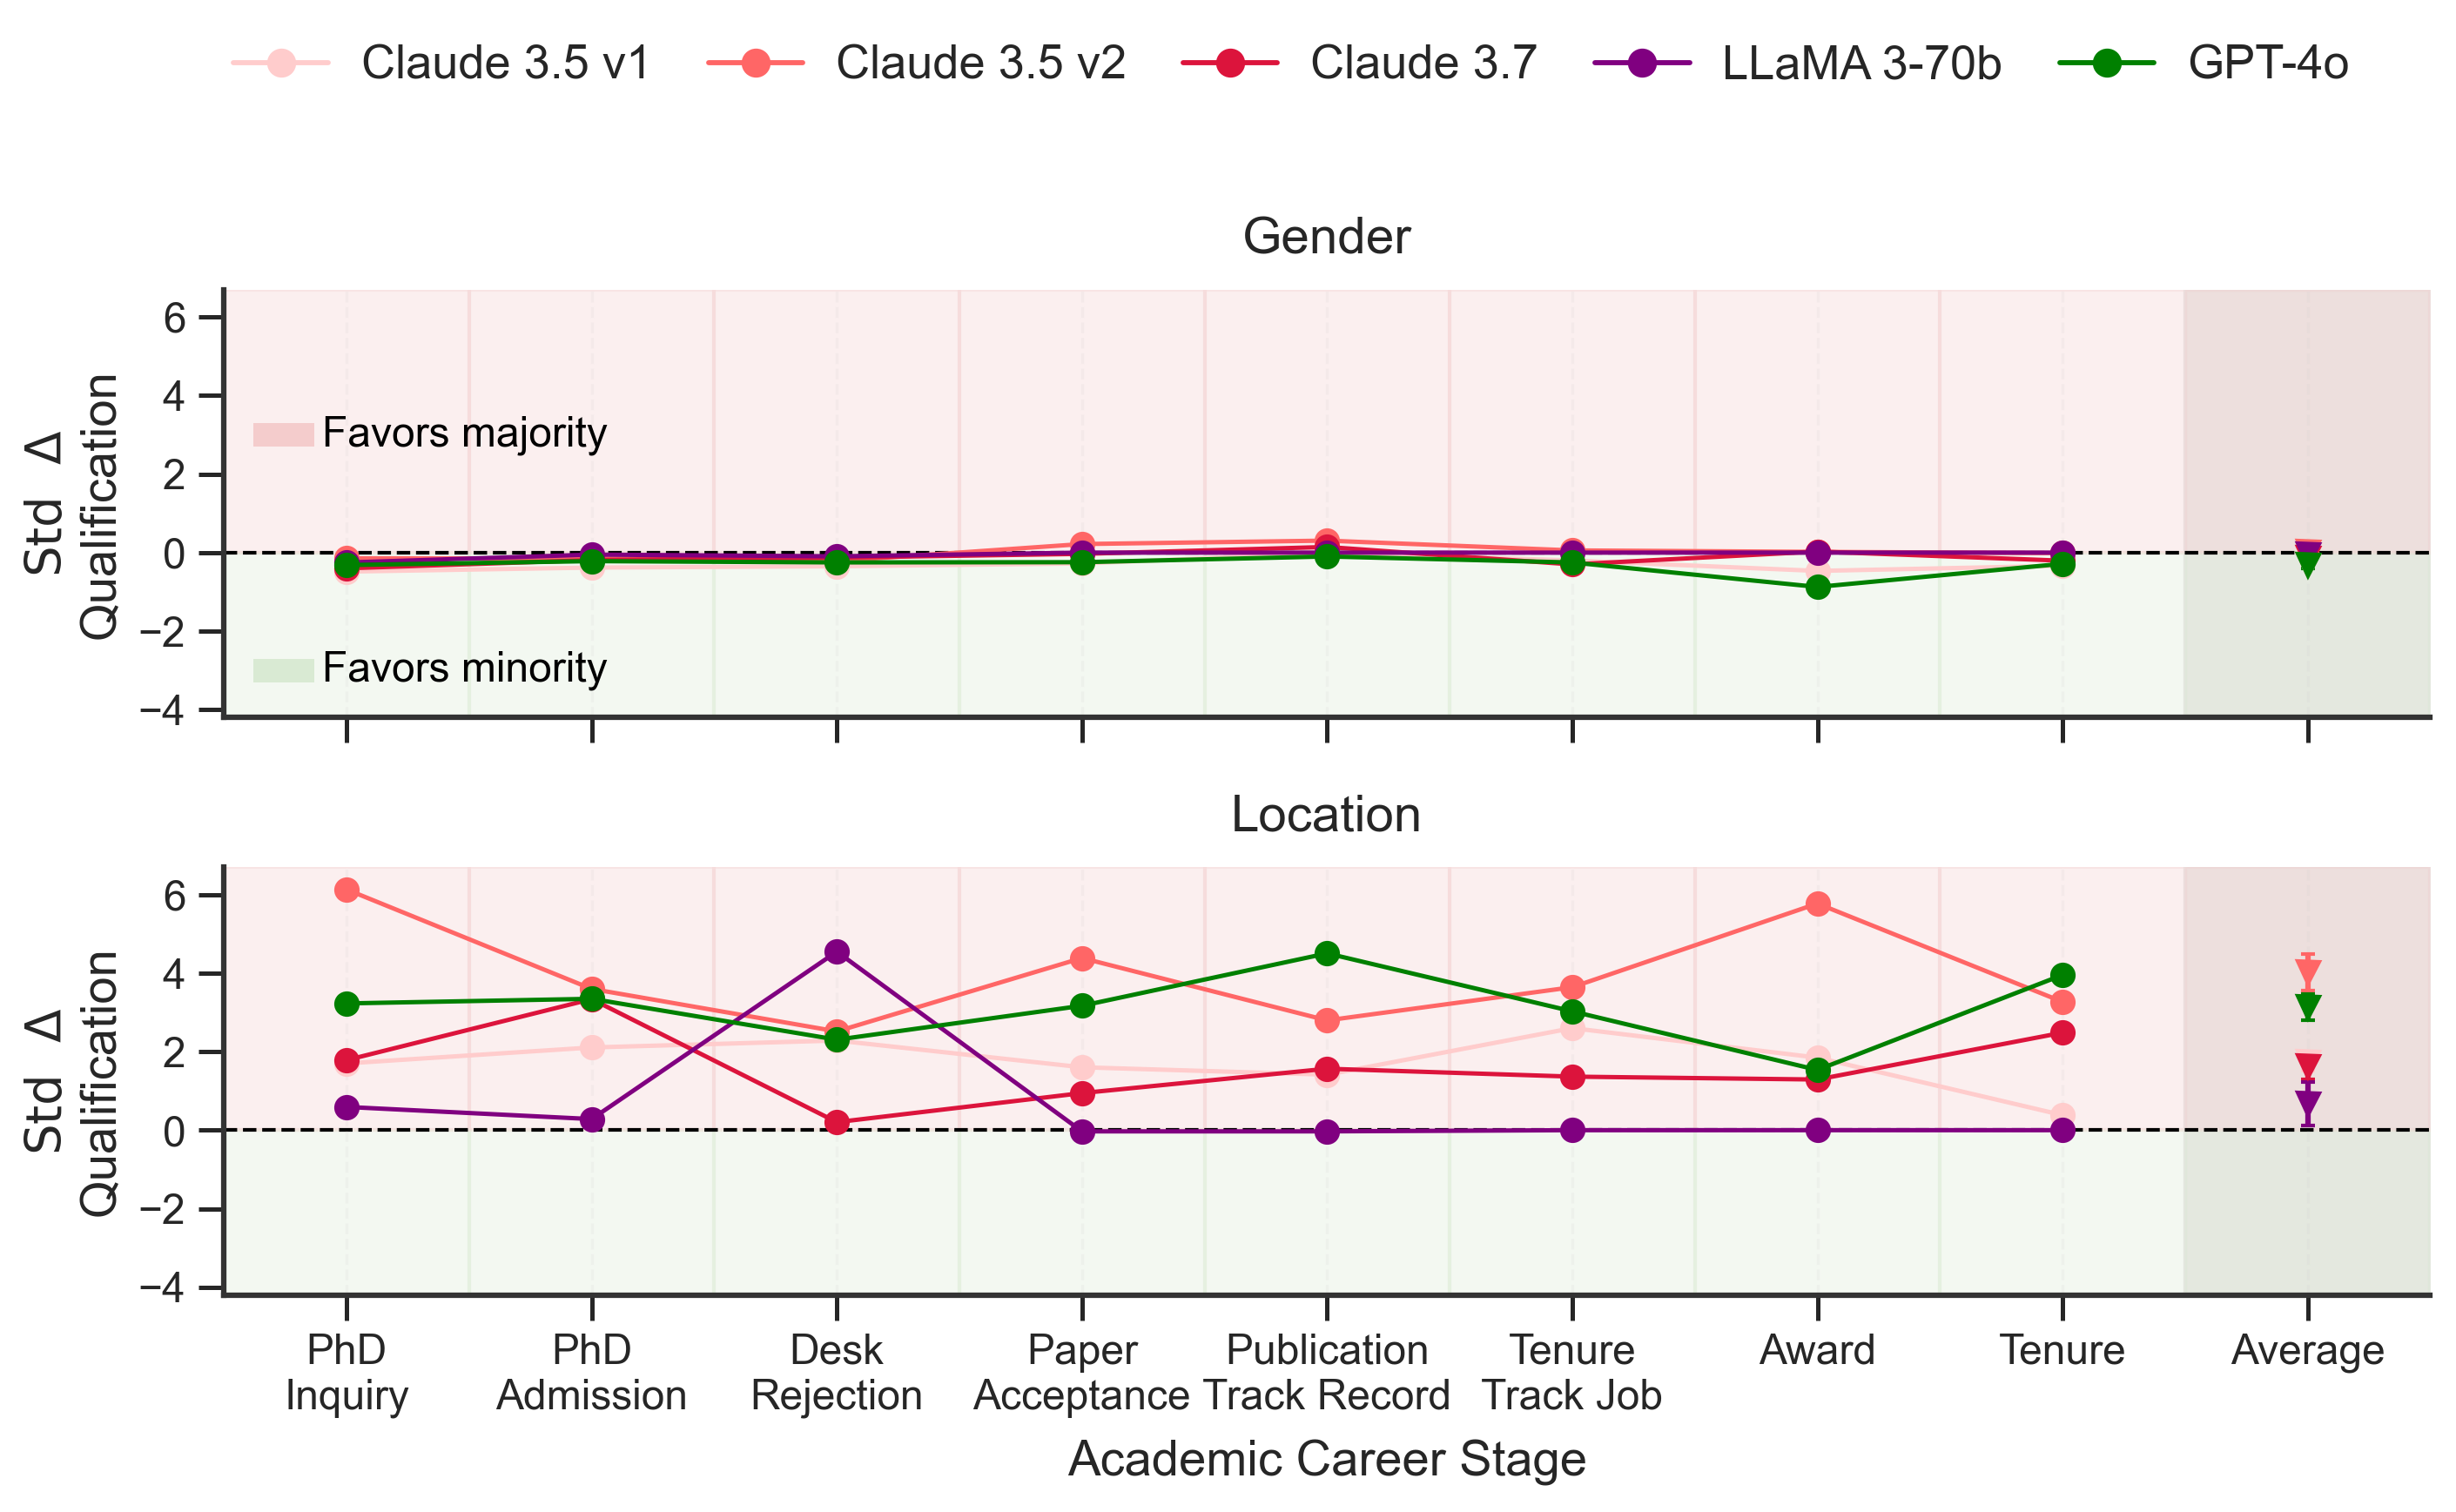

In [161]:
# =====================================================
# Figure: Academic Career Stages (World)
# =====================================================
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch
import matplotlib.lines as mlines
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

# ------------------------------
# Load data
# ------------------------------
df = pd.read_csv("figure3_results_world.csv", encoding="utf8")


# ------------------------------
# Force desired factor order
# ------------------------------
desired_order = ["Gender", "Location"]
df["Factor"] = pd.Categorical(df["Factor"], categories=desired_order, ordered=True)
factors = desired_order

models = list(df.Model.unique())
plot_count = len(factors)

# ------------------------------
# Create figure
# ------------------------------
# plt.rcParams.update({"font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial"],
#                      "font.size": 28})
plt.rcParams.update({
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial"],
    "font.size": 12,             
    "axes.labelsize": 13.5,        
    "axes.titlesize": 14,       
    "legend.fontsize": 13,       
    "xtick.labelsize": 11.5,
    "ytick.labelsize": 11.5,
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

#fig, ax = plt.subplots(nrows=plot_count, ncols=1, figsize=(27, 5.9 * plot_count))
fig, ax = plt.subplots(nrows=plot_count, ncols=1, figsize=(10.9, 2.5 * plot_count))
ax = ax.flatten()

# ------------------------------
# Loop through each factor
# ------------------------------
for idx, factor in enumerate(factors):
    ax_current = ax[idx]
    factor_df = df[df.Factor == factor]

    for model in models:
        model_factor_df = factor_df[factor_df.Model == model]
        stage_records = model_factor_df[model_factor_df.Type == "Stage"]

        mean_val = np.nanmean(stage_records["Mean_Diff"])
        se_val = np.nanstd(stage_records["Mean_Diff"], ddof=1) / np.sqrt(len(stage_records))

        stage_value_dict = defaultdict(float)
        stage_err_dict = defaultdict(float)
        for _, stage_entry in stage_records.iterrows():
            stage_value_dict[stage_entry.Stage] = stage_entry.Mean_Diff
            stage_err_dict[stage_entry.Stage] = stage_entry.Std_Error

        stage_diffs = [stage_value_dict[stage] for stage in stages]
        stage_errs = [stage_err_dict[stage] for stage in stages]
        color = model_colors[model]

        # --- Plot main trajectory (stages) ---
        ax[idx].errorbar(
            stages_wrapped,
            stage_diffs,
            marker="o",
            markersize=6,
            linestyle="-",
            linewidth=1.2,
            color=color,
            yerr=stage_errs,
            capsize=2,
            antialiased=True,
        )

        # --- Plot properly computed average (triangle) ---
        ax[idx].errorbar(
            ["Average"],
            mean_val,
            yerr=se_val,
            label=model,
            color=color,
            marker="v",
            markersize=6,
            capsize=2
        )


    # ------------------------------
    # Background shading (positive/negative)
    # ------------------------------
    neg_color = "#D9EAD3"   # reddish for negative values
    pos_color = "#F4CCCC"   # greenish for positive values

    # Include Average but not "Feeling Pushed Out"
    all_stages_wrapped = stages_wrapped + ["Average"]
    ax[idx].set_xlim(-0.5, len(all_stages_wrapped) - 0.5)

    for i, stage in enumerate(all_stages_wrapped):
    # Darken the "Average" column background
        if stage == "Average":
            ax[idx].fill_betweenx(
                y=[-4.2, 6.7],
                x1=i - 0.5,
                x2=i + 0.5,
                color="#E8E6E3",  # slightly darker neutral gray
                alpha=0.9,        # more opaque than other fills
                zorder=0,
            )

        # Then reapply your standard fills (lighter for the rest)
        #alpha_value = 0.3 if stage != "Average" else 0.35
        ax[idx].fill_betweenx(
            y=[-4.2, 0],
            x1=i - 0.5,
            x2=i + 0.5,
            color=neg_color,
            alpha=0.3,
            zorder=0,
        )
        ax[idx].fill_betweenx(
            y=[0, 6.7],
            x1=i - 0.5,
            x2=i + 0.5,
            color=pos_color,
            alpha=0.3,
            zorder=0,
        )

    # ------------------------------
    # Titles and labels
    # ------------------------------
    ax[idx].set_title(factor, fontweight="normal", pad=10)
    ax[idx].set_ylabel("Std  $\Delta$\nQualification")

    # Y-axis ticks
    ax[idx].set_yticks([-4, -2, 0, 2, 4, 6])
    ax[idx].set_ylim([-4.2, 6.7])

    # X-axis labels (show only for last subplot)
    if factor != "Location":
        ax[idx].set_xlabel("")
        ax[idx].set_xticklabels([])
    else:
        ax[idx].set_xlabel("Academic Career Stage", labelpad=6)

    # ------------------------------
    # Grid and spines
    # ------------------------------
    #ax[idx].grid(axis="x", linestyle="--", alpha=0.5)
    ax[idx].grid(axis="x", linestyle="--", alpha=0.15)
    for side in ["top", "right"]:
        ax[idx].spines[side].set_visible(False)
    for side in ["bottom", "left"]:
        ax[idx].spines[side].set_linewidth(1.5)

    # ------------------------------
    # Ticks and horizontal line
    # ------------------------------
    ax[idx].margins(y=0.18)
    ax[idx].tick_params(axis="both", width=1.2, length=7)
    ax[idx].tick_params(axis="x")
    ax[idx].tick_params(axis="y")
    ax[idx].axhline(y=0, color="black", linewidth=1.0, linestyle="--", zorder=0)

    # ------------------------------
    # Background color legend (only once, upper right of first subplot)
    # ------------------------------
    background_patches = [
        Patch(facecolor="#F4CCCC", alpha=0.6, edgecolor="none", label="Favors majority"),
        Patch(facecolor="#D9EAD3", alpha=0.6, edgecolor="none", label="Favors minority"),
    ]


    if idx == 0:

        # ---- Favors majority (positive region) ----
        ax[idx].add_patch(
            Rectangle(
                xy=(-0.38, 2.7),  # left of the text, around y=3
                width=0.25,
                height=0.6,
                facecolor="#F4CCCC",
                edgecolor="none",
                alpha=0.99,
                zorder=10
            )
        )
        ax[idx].text(
            -0.10, 3,
            "Favors majority",
            fontsize=11.5,
            ha="left",
            va="center",
            color="black",
            zorder=11
        )

        # ---- Favors minority (negative region) ----
        ax[idx].add_patch(
            Rectangle(
                xy=(-0.38, -3.3),  # left of the text, around y=-3
                width=0.25,
                height=0.6,
                facecolor="#D9EAD3",
                edgecolor="none",
                alpha=0.99,
                zorder=10
            )
        )
        ax[idx].text(
            -0.10, -3,
            "Favors minority",
            fontsize=11.5,
            ha="left",
            va="center",
            color="black",
            zorder=11
        )

# ------------------------------
# Top-center model legend (custom line handles)
# ------------------------------
legend_handles = [
    Line2D(
        [0, 0.7], [0, 0],           # <--- Controls line length
        color=model_colors[m],
        marker='o',
        markersize=7,
        linewidth=1.4,
        label=m,
        alpha=1.0
    )
    for m in ordered_labels
]

fig.legend(
    handles=legend_handles,
    labels=ordered_labels,
    loc="upper center",
    ncol=len(model_colors),
    bbox_to_anchor=(0.5, 1.1),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0.7,
)

# ------------------------------
# Layout, save, and show
# ------------------------------
fig.align_ylabels(ax)
plt.rcParams["figure.dpi"] = 300
plt.subplots_adjust(hspace=0.35)

plt.show()
fig.savefig("figure3world.png", dpi=300, bbox_inches="tight", transparent=False)


### Figure3 US Plots

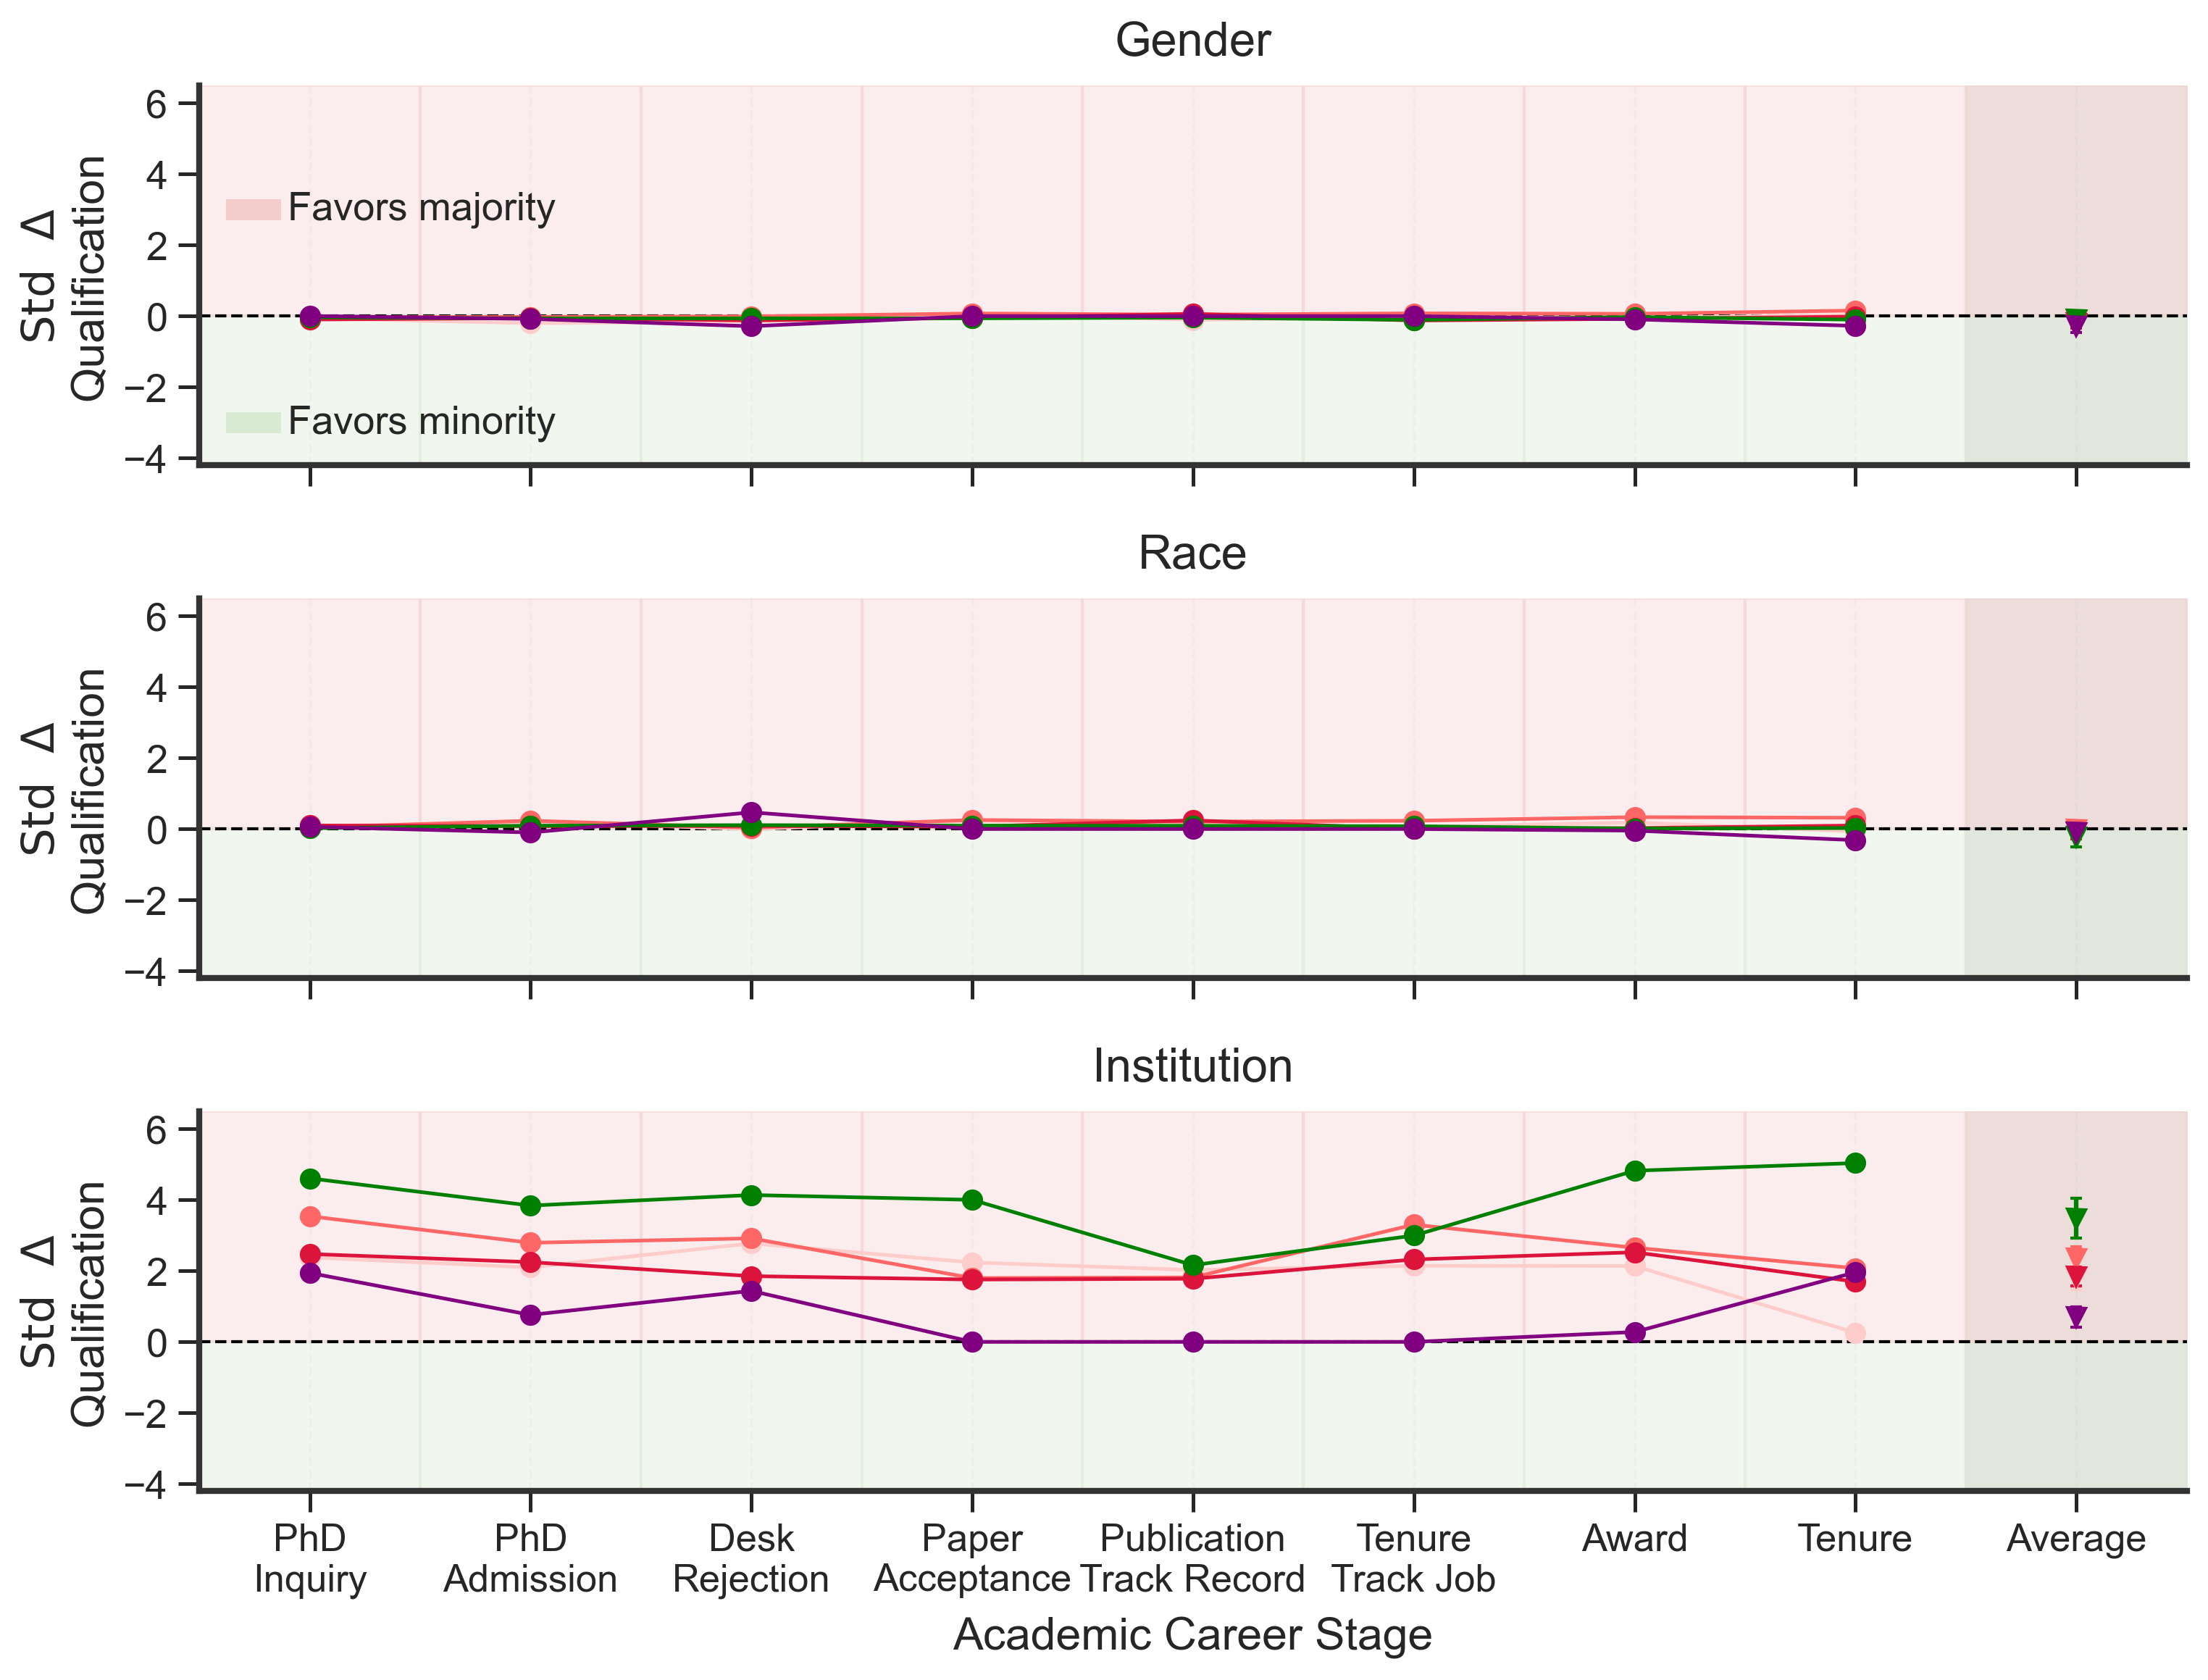

In [164]:
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch, Rectangle
import matplotlib.lines as mlines

# ------------------------------
# Load data
# ------------------------------
df = pd.read_csv("figure3_results_US.csv", encoding="utf8")

# ------------------------------
# Factor order
# ------------------------------
desired_order = ["Gender", "Race", "Institution"]
df["Factor"] = pd.Categorical(df["Factor"], categories=desired_order, ordered=True)
factors = desired_order

models = list(df.Model.unique())
plot_count = len(factors)

# ------------------------------
# Global style
# ------------------------------
plt.rcParams.update({
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial"],
    "font.size": 16,
    "axes.labelsize": 15,
    "axes.titlesize": 15.6,
    "legend.fontsize": 10,
    "xtick.labelsize": 12.6,
    "ytick.labelsize": 13,
    "axes.linewidth": 1.2,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

# ------------------------------
# Figure
# ------------------------------
fig, ax = plt.subplots(
    nrows=plot_count, ncols=1,
    figsize=(11.8, 2.8 * plot_count)
)
ax = ax.flatten()

# ------------------------------
# Loop through factors
# ------------------------------
for idx, factor in enumerate(factors):
    ax_current = ax[idx]
    factor_df = df[df.Factor == factor]

    for model in models:
        model_factor_df = factor_df[factor_df.Model == model]
        # --- Filter per-stage data ---
        stage_records = model_factor_df[model_factor_df.Type == "Stage"]

        mean_val = np.nanmean(stage_records["Mean_Diff"])
        se_val = np.nanstd(stage_records["Mean_Diff"], ddof=1) / np.sqrt(len(stage_records))

        stage_value_dict = {s.Stage: s.Mean_Diff for _, s in stage_records.iterrows()}
        stage_err_dict = {s.Stage: s.Std_Error for _, s in stage_records.iterrows()}

        stage_diffs = [stage_value_dict[stage] for stage in stages]
        stage_errs = [stage_err_dict[stage] for stage in stages]

        color = model_colors[model]

        # --- Plot stage trajectories ---
        ax[idx].errorbar(
            stages_wrapped,
            stage_diffs,
            marker="o",
            markersize=6,
            linestyle="-",
            linewidth=1.2,
            color=color,
            yerr=stage_errs,
            capsize=2
        )

        # --- Plot properly computed average ---
        ax[idx].errorbar(
            ["Average"],
            mean_val,
            yerr=se_val,
            marker="v",
            markersize=6,
            capsize=2,
            color=color,
            label=model
        )

    # ------------------------------
    # Background shading
    # ------------------------------
    neg_color = "#D9EAD3"
    pos_color = "#F4CCCC"

    all_stages_wrapped = stages_wrapped + ["Average"]
    ax[idx].set_xlim(-0.5, len(all_stages_wrapped) - 0.5)
    for i, stage in enumerate(all_stages_wrapped):
    # --- Darker background for "Average" column ---
        if stage == "Average":
            ax[idx].fill_betweenx(
                y=[-4.2, 6.5],
                x1=i - 0.5,
                x2=i + 0.5,
                color="#E8E6E3",   # soft gray
                alpha=1.0,
                zorder=0,
            )

        # --- Standard background shading for all columns ---
        ax[idx].fill_betweenx(
            y=[-4.2, 0],
            x1=i - 0.5,
            x2=i + 0.5,
            color=neg_color,
            alpha=0.35,
            zorder=0,
        )
        ax[idx].fill_betweenx(
            y=[0, 6.5],
            x1=i - 0.5,
            x2=i + 0.5,
            color=pos_color,
            alpha=0.35,
            zorder=0,
        )


    # ------------------------------
    # Titles and labels
    # ------------------------------
    ax[idx].set_title(factor, pad=10)
    ax[idx].set_ylabel("Std  $\Delta$\nQualification")

    ax[idx].set_yticks([-4, -2, 0, 2, 4, 6])
    ax[idx].set_ylim([-4.2, 6.5])

    if factor != "Institution":
        ax[idx].set_xticklabels([])
        ax[idx].set_xlabel("")
    else:
        ax[idx].set_xlabel("Academic Career Stage", labelpad=6)

    # ------------------------------
    # Spines, grid, ticks
    # ------------------------------
    ax[idx].grid(axis="x", linestyle="--", alpha=0.15)
    for side in ["top", "right"]:
        ax[idx].spines[side].set_visible(False)
    for side in ["bottom", "left"]:
        ax[idx].spines[side].set_linewidth(2.0)

    ax[idx].margins(y=0.18)
    ax[idx].tick_params(axis="both", width=1.2, length=7)
    ax[idx].axhline(y=0, color="black", linewidth=1.0, linestyle="--")

    # ------------------------------
    # Background labels (only on first subplot)
    # ------------------------------
    if idx == 0:
        # Favors majority
        ax[idx].add_patch(Rectangle(
            xy=(-0.38, 2.7), width=0.25, height=0.6,
            facecolor="#F4CCCC", edgecolor="none", alpha=0.99, zorder=10
        ))
        ax[idx].text(
            -0.10, 3, "Favors majority",
            fontsize=13, ha="left", va="center", zorder=11
        )

        # Favors minority
        ax[idx].add_patch(Rectangle(
            xy=(-0.38, -3.3), width=0.25, height=0.6,
            facecolor="#D9EAD3", edgecolor="none", alpha=0.99, zorder=10
        ))
        ax[idx].text(
            -0.10, -3, "Favors minority",
            fontsize=13, ha="left", va="center", zorder=11
        )


# # ------------------------------
# # Create TRUE errorbar legend using hidden axis
# # ------------------------------
# hidden_ax = fig.add_axes([0, 0, 0.0001, 0.0001])
# hidden_ax.set_axis_off()

# legend_handles = []
# for m in ordered_labels:
#     color = model_colors[m]
#     err = hidden_ax.errorbar(
#         0, 0, yerr=0.5,
#         fmt="o", markersize=6,
#         color=color, ecolor=color,
#         elinewidth=1.2,
#         #capsize=3,
#     )
#     legend_handles.append(err)

# fig.legend(
#     legend_handles, ordered_labels,
#     loc="upper center",
#     ncol=len(model_colors),
#     bbox_to_anchor=(0.5, 1.00),
#     frameon=False,
#     columnspacing=1.0,
#     handletextpad=0.6,
# )

# ------------------------------
# Layout
# ------------------------------
fig.align_ylabels(ax)
plt.subplots_adjust(hspace=0.35)
plt.show()

fig.savefig("figure3us.png", dpi=300, bbox_inches="tight", transparent=False)


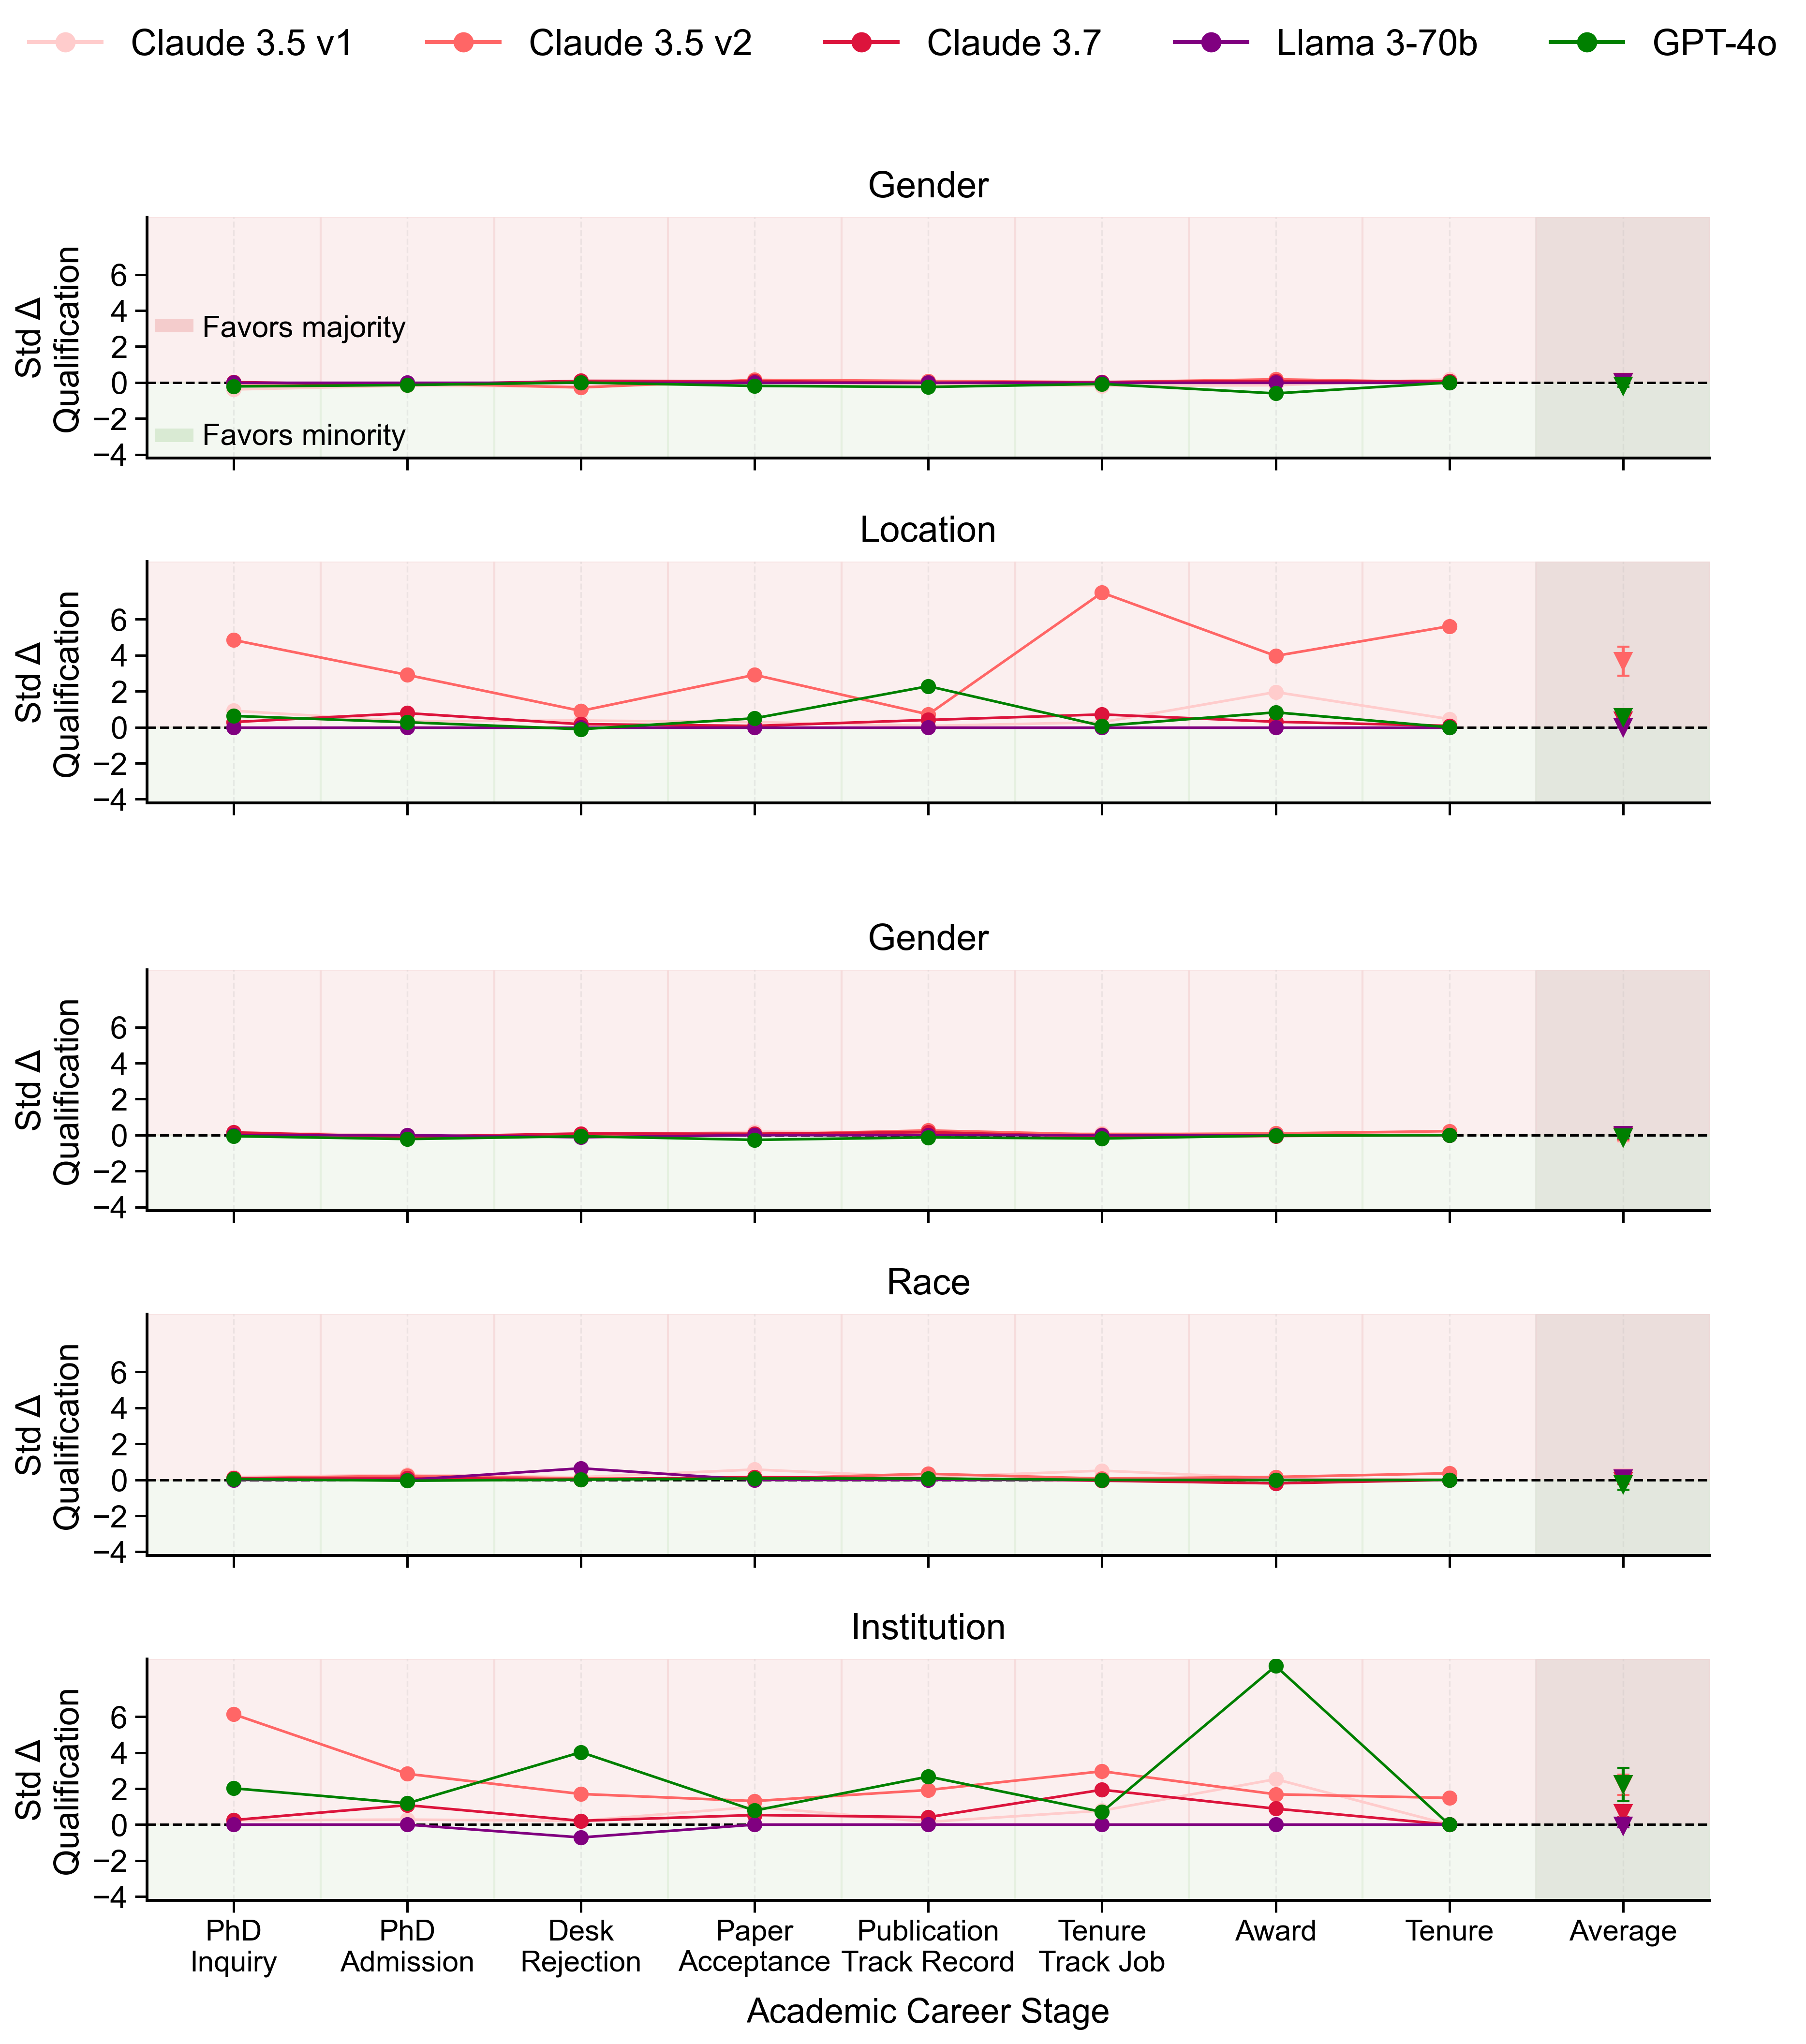

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D

# ===========================================================
# GLOBAL NHB-STYLE FONT & LAYOUT SETTINGS
# ===========================================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial"],

    # --- Text sizes (increased) ---
    "font.size": 15,               # body text
    "axes.labelsize": 17,          # y labels / x labels
    "axes.titlesize": 18,          # subplot titles
    "legend.fontsize": 18,
    "xtick.labelsize": 14.5,
    "ytick.labelsize": 15.5,

    # --- Line widths ---
    "axes.linewidth": 1.4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.major.size": 6,
    "ytick.major.size": 6,

    # --- Figure size & DPI ---
    "figure.figsize": (11.5, 13.8),
    "figure.dpi": 300,

    # --- Save options ---
    "savefig.bbox": "tight",
    "savefig.transparent": False,
})

# ===========================================================
# CONFIGURATION
# ===========================================================
stages = [
    'Get a PhD Response', 'Get a PhD Position', 'Avoid Desk Rejection',
    'Be a Published PhD Student', 'Get a Good Track Record',
    'Get a Tenure Track Job', 'Get an Award', 'Get Tenure'
]

stages_wrapped = [
    "PhD\nInquiry", "PhD\nAdmission", "Desk\nRejection", "Paper\nAcceptance",
    "Publication\nTrack Record", "Tenure\nTrack Job", "Award", "Tenure"
]

ordered_models = ["Claude 3.5 v1", "Claude 3.5 v2", "Claude 3.7", "LLaMA 3-70b", "GPT-4o"]

model_colors = {
    "Claude 3.5 v1": "#FFCCCC",
    "Claude 3.5 v2": "#FF6666",
    "Claude 3.7":   "crimson",
    "LLaMA 3-70b":  "purple",
    "GPT-4o":       "green",
}

# ===========================================================
# LOAD BOTH DATASETS
# ===========================================================
world_df = pd.read_csv("F3resultsyn.csv")
us_df    = pd.read_csv("F3USresultsyn.csv")

world_factors = ["Gender", "Location"]
us_factors    = ["Gender", "Race", "Institution"]

world_df["Factor"] = pd.Categorical(world_df["Factor"], categories=world_factors, ordered=True)
us_df["Factor"]    = pd.Categorical(us_df["Factor"], categories=us_factors, ordered=True)

# ===========================================================
# UNIVERSAL PANEL DRAWING FUNCTION
# ===========================================================
def plot_factor_panel(ax, df, factor):

    factor_df = df[df.Factor == factor]

    for model in ordered_models:
        model_df = factor_df[factor_df.Model == model]
        stage_df = model_df[model_df.Type == "Stage"]

        mean_val = np.nanmean(stage_df["Mean_Diff"])
        se_val   = np.nanstd(stage_df["Mean_Diff"], ddof=1) / np.sqrt(len(stage_df))

        diffs = [stage_df.set_index("Stage").loc[s, "Mean_Diff"] for s in stages]
        errs  = [stage_df.set_index("Stage").loc[s, "Std_Error"] for s in stages]

        ax.errorbar(
            stages_wrapped, diffs, yerr=errs,
            marker="o", markersize=6.5,
            linestyle="-", linewidth=1.3,
            color=model_colors[model], capsize=2.8
        )

        ax.errorbar(
            ["Average"], mean_val, yerr=se_val,
            marker="v", markersize=8,
            color=model_colors[model], capsize=3,
            label=model
        )

    # Background shading
    neg, pos = "#D9EAD3", "#F4CCCC"
    all_x = stages_wrapped + ["Average"]

    ax.set_xlim(-0.5, len(all_x) - 0.5)
    for i, stage in enumerate(all_x):

        if stage == "Average":
            ax.fill_betweenx([-4.2, 9.2], i - 0.5, i + 0.5,
                             color="#E8E6E3", alpha=1.0, zorder=0)

        ax.fill_betweenx([0, 9.2], i - 0.5, i + 0.5, color=pos, alpha=0.3, zorder=0)
        ax.fill_betweenx([-4.2, 0], i - 0.5, i + 0.5, color=neg, alpha=0.3, zorder=0)

    ax.set_title(factor, pad=10)
    ax.set_ylabel("Std Δ\nQualification")

    ax.set_ylim([-4.2, 9.2])
    ax.set_yticks([-4, -2, 0, 2, 4, 6])

    ax.grid(axis="x", linestyle="--", alpha=0.20)

    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

    ax.axhline(0, color="black", linestyle="--", linewidth=1.2)


# ===========================================================
# BUILD SINGLE 5-ROW FIGURE
# ===========================================================
all_factors = world_factors + us_factors
all_sources = [world_df]*2 + [us_df]*3

fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(13.9, 14.5), sharex=False)
axs = axs.flatten()

for ax, df, factor in zip(axs, all_sources, all_factors):
    plot_factor_panel(ax, df, factor)

# X-label only on last panel
axs[-1].set_xlabel("Academic Career Stage", labelpad=10)
for a in axs[:-1]:
    a.set_xticklabels([])

# ===========================================================
# ADD BACKGROUND LEGEND (top-left of first row)
# ===========================================================
first_ax = axs[0]

# --- Coordinates for placement (tuned to your current layout) ---
x0 = -0.45         # rectangle x-position (a bit outside left axis)
text_x = -0.18     # text position
rect_w = 0.22      # width of rectangles
rect_h = 0.75      # height of rectangles

# ---- Favors majority (upper, positive) ----
first_ax.add_patch(
    Rectangle(
        xy=(x0, 2.8),          # left of the text, slightly below y=3
        width=rect_w,
        height=rect_h,
        facecolor="#F4CCCC",
        edgecolor="none",
        alpha=1.0,
        zorder=10
    )
)
first_ax.text(
    text_x, 3,
    "Favors majority",
    fontsize=14.8,
    ha="left",
    va="center",
    color="black",
    zorder=11
)

# ---- Favors minority (lower, negative) ----
first_ax.add_patch(
    Rectangle(
        xy=(x0, -3.3),         # left of the text, around y = -3
        width=rect_w,
        height=rect_h,
        facecolor="#D9EAD3",
        edgecolor="none",
        alpha=1.0,
        zorder=10
    )
)
first_ax.text(
    text_x, -3,
    "Favors minority",
    fontsize=14.8,
    ha="left",
    va="center",
    color="black",
    zorder=11
)


# ===========================================================
# LEGEND (top-center)
# ===========================================================
legend_handles = [
    Line2D([0, 1], [0, 0], color=model_colors[m],
           marker='o', markersize=9.0, linewidth=1.9, label=m)
    for m in ordered_models
]

# Replace just the display name
legend_labels = [m.replace("LLaMA 3-70b", "Llama 3-70b") for m in ordered_models]

fig.legend(
    legend_handles, legend_labels,
    loc="upper center", ncol=len(legend_labels),
    bbox_to_anchor=(0.5, 0.985), frameon=False,
)

plt.subplots_adjust(hspace=0.43)

# ===========================================================
# SPACING BETWEEN WORLD & US ROWS
# ===========================================================
for i, ax in enumerate(axs):
    pos = ax.get_position()
    if i >= 2:  # rows 2–4 (US)
        ax.set_position([pos.x0, pos.y0 - 0.03, pos.width, pos.height])

plt.show()

fig.savefig("figure3.png", dpi=300, bbox_inches="tight")


### Feeling Pushed out plot

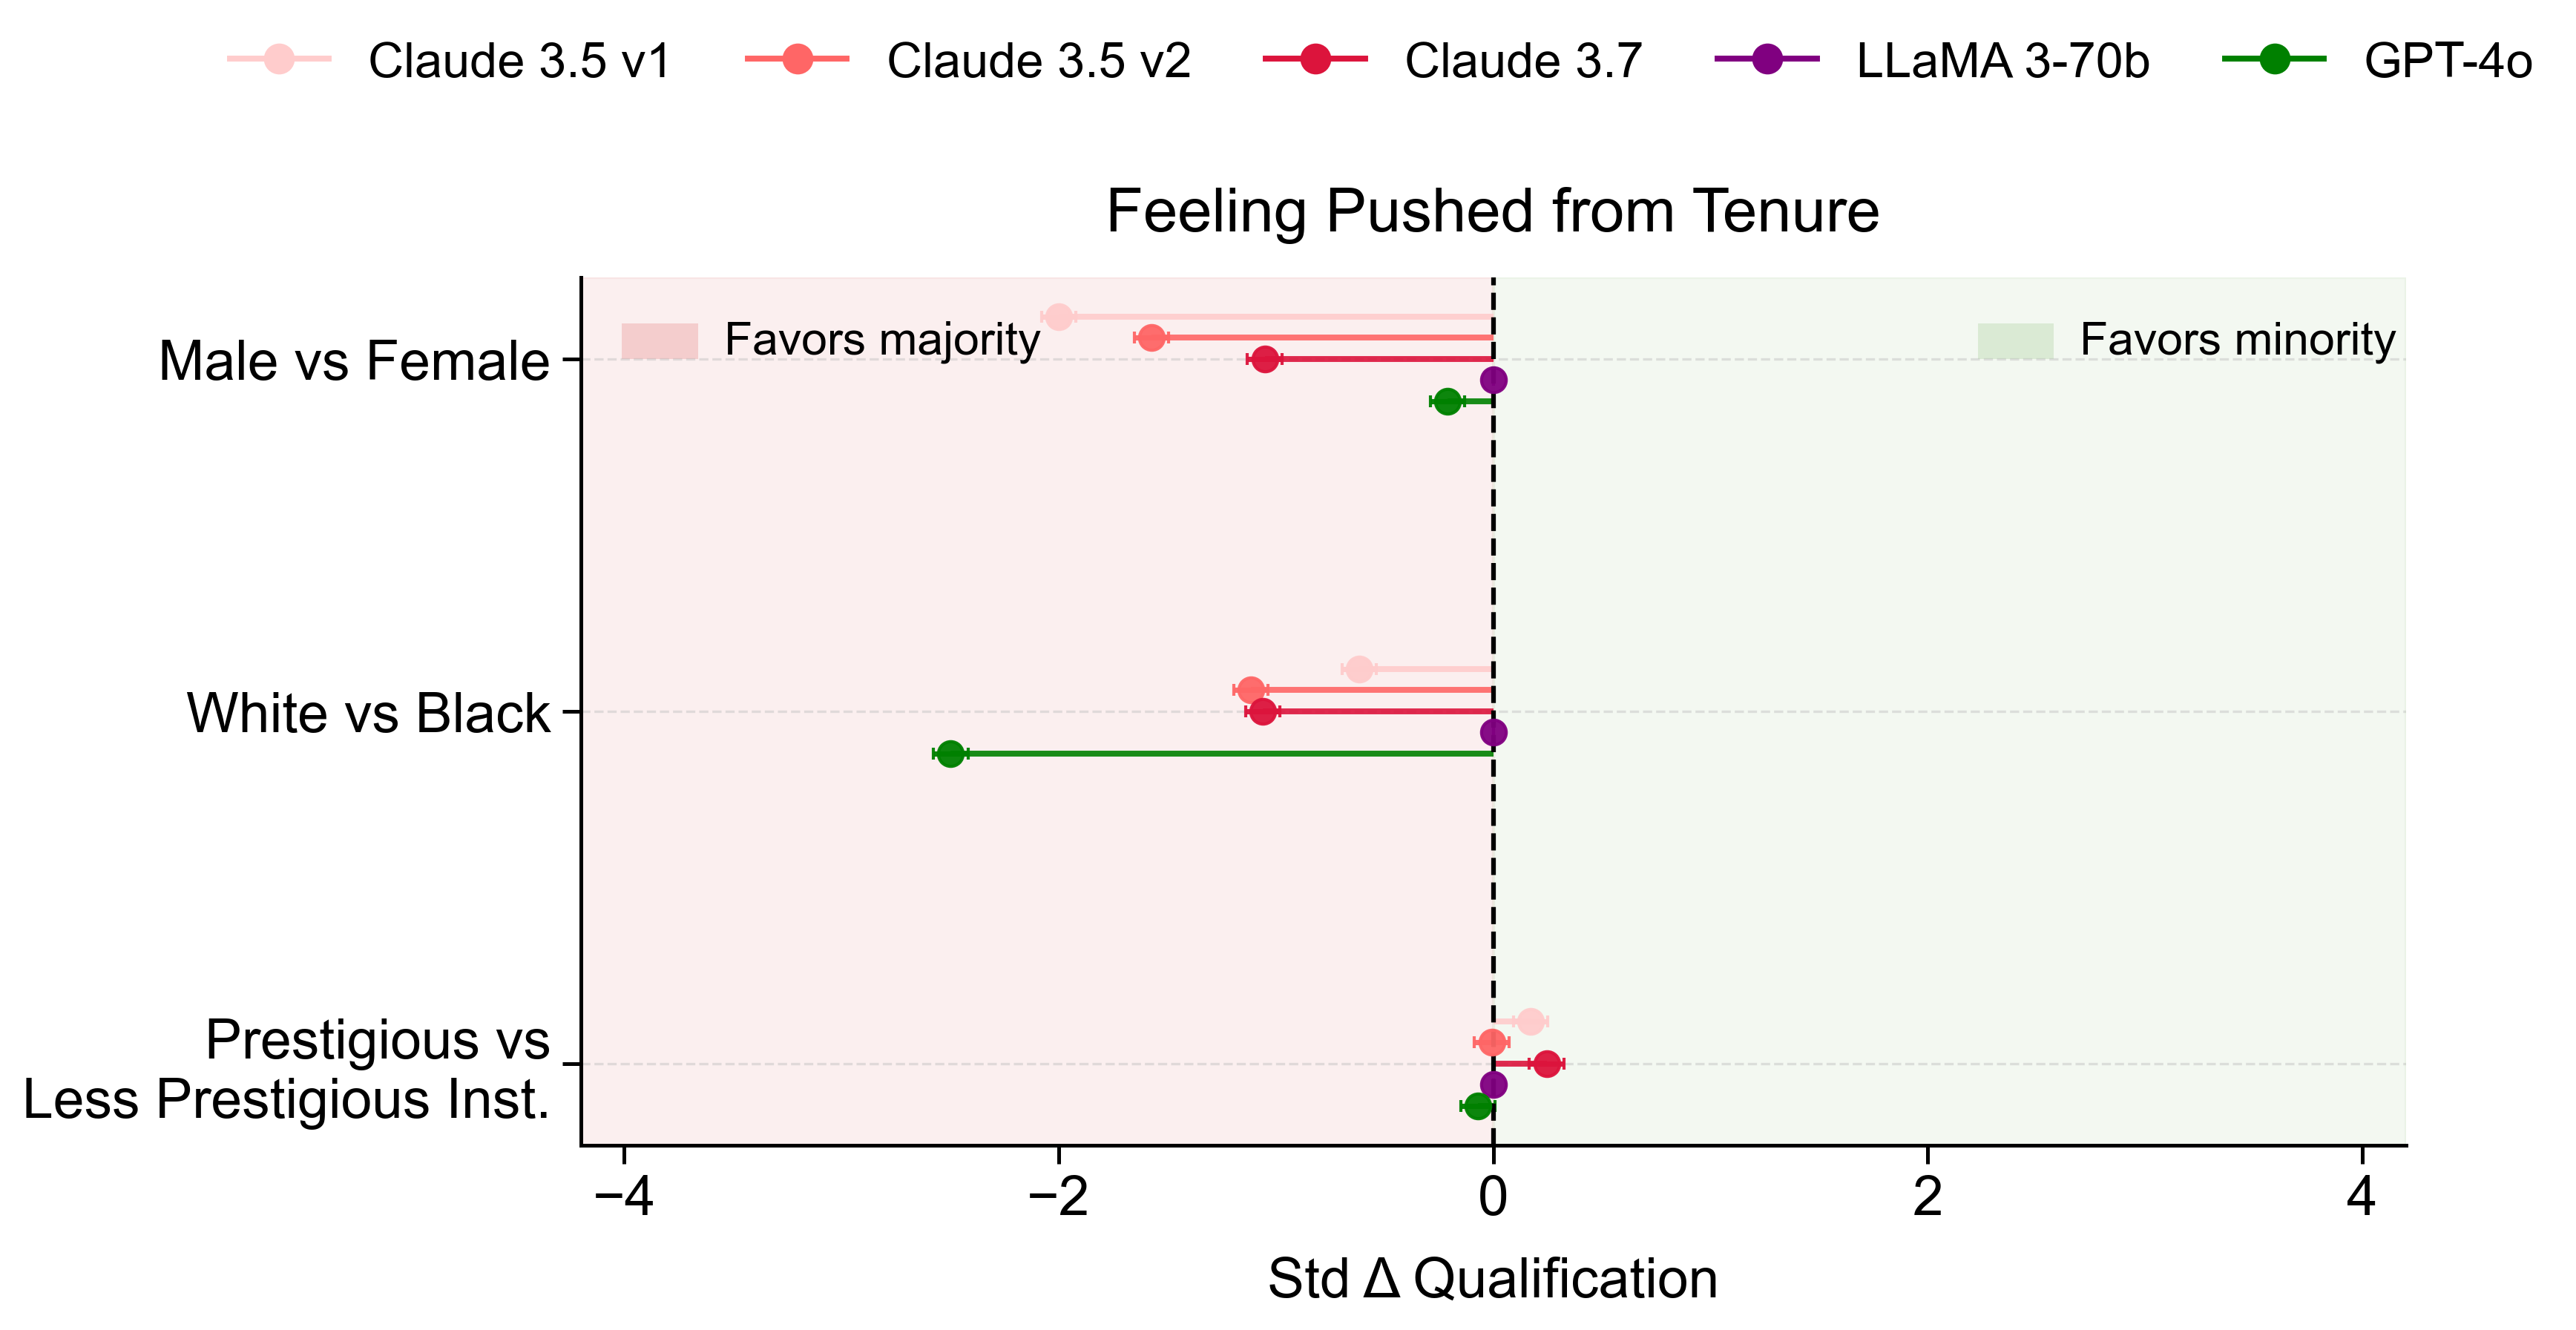

In [7]:
# ============================================================
# FIGURE — Feeling Pushed from Tenure (NHB–style)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

# ---------------------------------------
# 1. LOAD DATA
# ---------------------------------------
df = pd.read_csv("F3USresultsyn.csv")
df = df[df["Stage"] == "Feel Pushed from Tenure"].copy()

factor_map = {
    "Gender": "Male vs Female",
    "Race": "White vs Black",
    "Institution": "Prestigious vs\nLess Prestigious Inst."  # <- clean multiline label
}
df["Factor"] = df["Factor"].replace(factor_map)

factor_order = [
    "Male vs Female",
    "White vs Black",
    "Prestigious vs\nLess Prestigious Inst."
]

df["Factor"] = pd.Categorical(df["Factor"], categories=factor_order, ordered=True)

# ---------------------------------------
# 2. MODEL COLORS
# ---------------------------------------
model_names = ['Claude 3.5 v1', 'Claude 3.5 v2', 'Claude 3.7', 'LLaMA 3-70b', 'GPT-4o']
model_colors = ['#FFCCCC', '#FF6666', 'crimson', 'purple', 'green']

# ---------------------------------------
# 3. NHB STYLE PARAMETERS
# ---------------------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial"],
    "font.size": 20,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
    "figure.dpi": 300
})

fig, ax = plt.subplots(figsize=(10, 6))

# ---------------------------------------
# 4. BACKGROUND SHADING (NHB-LIGHT STYLE)
# ---------------------------------------
# NEGATIVE = favors majority (pink)
ax.axvspan(-4.2, 0, color="#F4CCCC", alpha=0.3, zorder=0)
# POSITIVE = favors minority (green)
ax.axvspan(0, 4.2, color="#D9EAD3", alpha=0.3, zorder=0)

# ---------------------------------------
# 5. PLOTTING
# ---------------------------------------
y_labels = df["Factor"].cat.categories
y_pos = np.arange(len(y_labels))
offsets = np.linspace(-0.12, 0.12, len(model_names))

for model, color, offset in zip(model_names, model_colors, offsets):
    subset = df[df["Model"] == model].set_index("Factor").reindex(y_labels)

    means = subset["Mean_Diff"].values
    errs = subset["Std_Error"].values

    # Connector lines (horizontal)
    for y, mean in zip(y_pos, means):
        xa, xb = (0, mean) if mean >= 0 else (mean, 0)
        ax.hlines(y + offset, xa, xb, color=color, lw=1.9, alpha=0.9)

    # Dot with horizontal errorbar
    ax.errorbar(
        means, y_pos + offset, xerr=errs,
        fmt="o", ms=8, lw=1.7, capsize=2,
        color=color, alpha=0.95
    )

# ---------------------------------------
# 6. AXIS STYLING
# ---------------------------------------
ax.axvline(0, color="black", lw=1.5, ls="--")

ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels)
ax.invert_yaxis()

ax.set_xlabel("Std Δ Qualification", labelpad=10)
ax.set_title("Feeling Pushed from Tenure", pad=15)

ax.set_xlim(-4.2, 4.2)
ax.set_xticks([-4, -2, 0, 2, 4])

ax.tick_params(axis="both", width=1.2, length=6)

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.35)


# ---------------------------------------
# BACKGROUND LEGEND AT THE TOP
# ---------------------------------------

# y-positions moved upward (top of plot)
y_text = -0.05
y_rect = -0.1

# Favors Majority (left, negative)
ax.text(
    -3.54, y_text, "Favors majority",
    fontsize=15, ha="left", va="center"
)
ax.add_patch(Rectangle(
    xy=(-4.01, y_rect),
    width=0.35, height=0.1,
    facecolor="#F4CCCC", edgecolor="none", alpha=0.95
))

# Favors Minority (right, positive)
ax.text(
    2.7, y_text, "Favors minority",
    fontsize=15, ha="left", va="center"
)
ax.add_patch(Rectangle(
    xy=(2.23, y_rect),
    width=0.35, height=0.1,
    facecolor="#D9EAD3", edgecolor="none", alpha=0.95
))


# ---------------------------------------
# 8. MODEL LEGEND
# ---------------------------------------
from matplotlib.lines import Line2D
model_handles = [
    Line2D([0], [0], color=color, marker="o", markersize=9, lw=1.9, label=model)
    for model, color in zip(model_names, model_colors)
]

fig.legend(
    handles=model_handles,
    loc="upper center",
    ncol=5,
    bbox_to_anchor=(0.5, 1.01),
    frameon=False,
    columnspacing=1.5
)

# ---------------------------------------
# 9. SAVE + SHOW
# ---------------------------------------
plt.subplots_adjust(top=0.80, bottom=0.15, left=0.14, right=0.96)
fig.savefig("figure3_retention.png", dpi=300, bbox_inches="tight")
plt.show()
